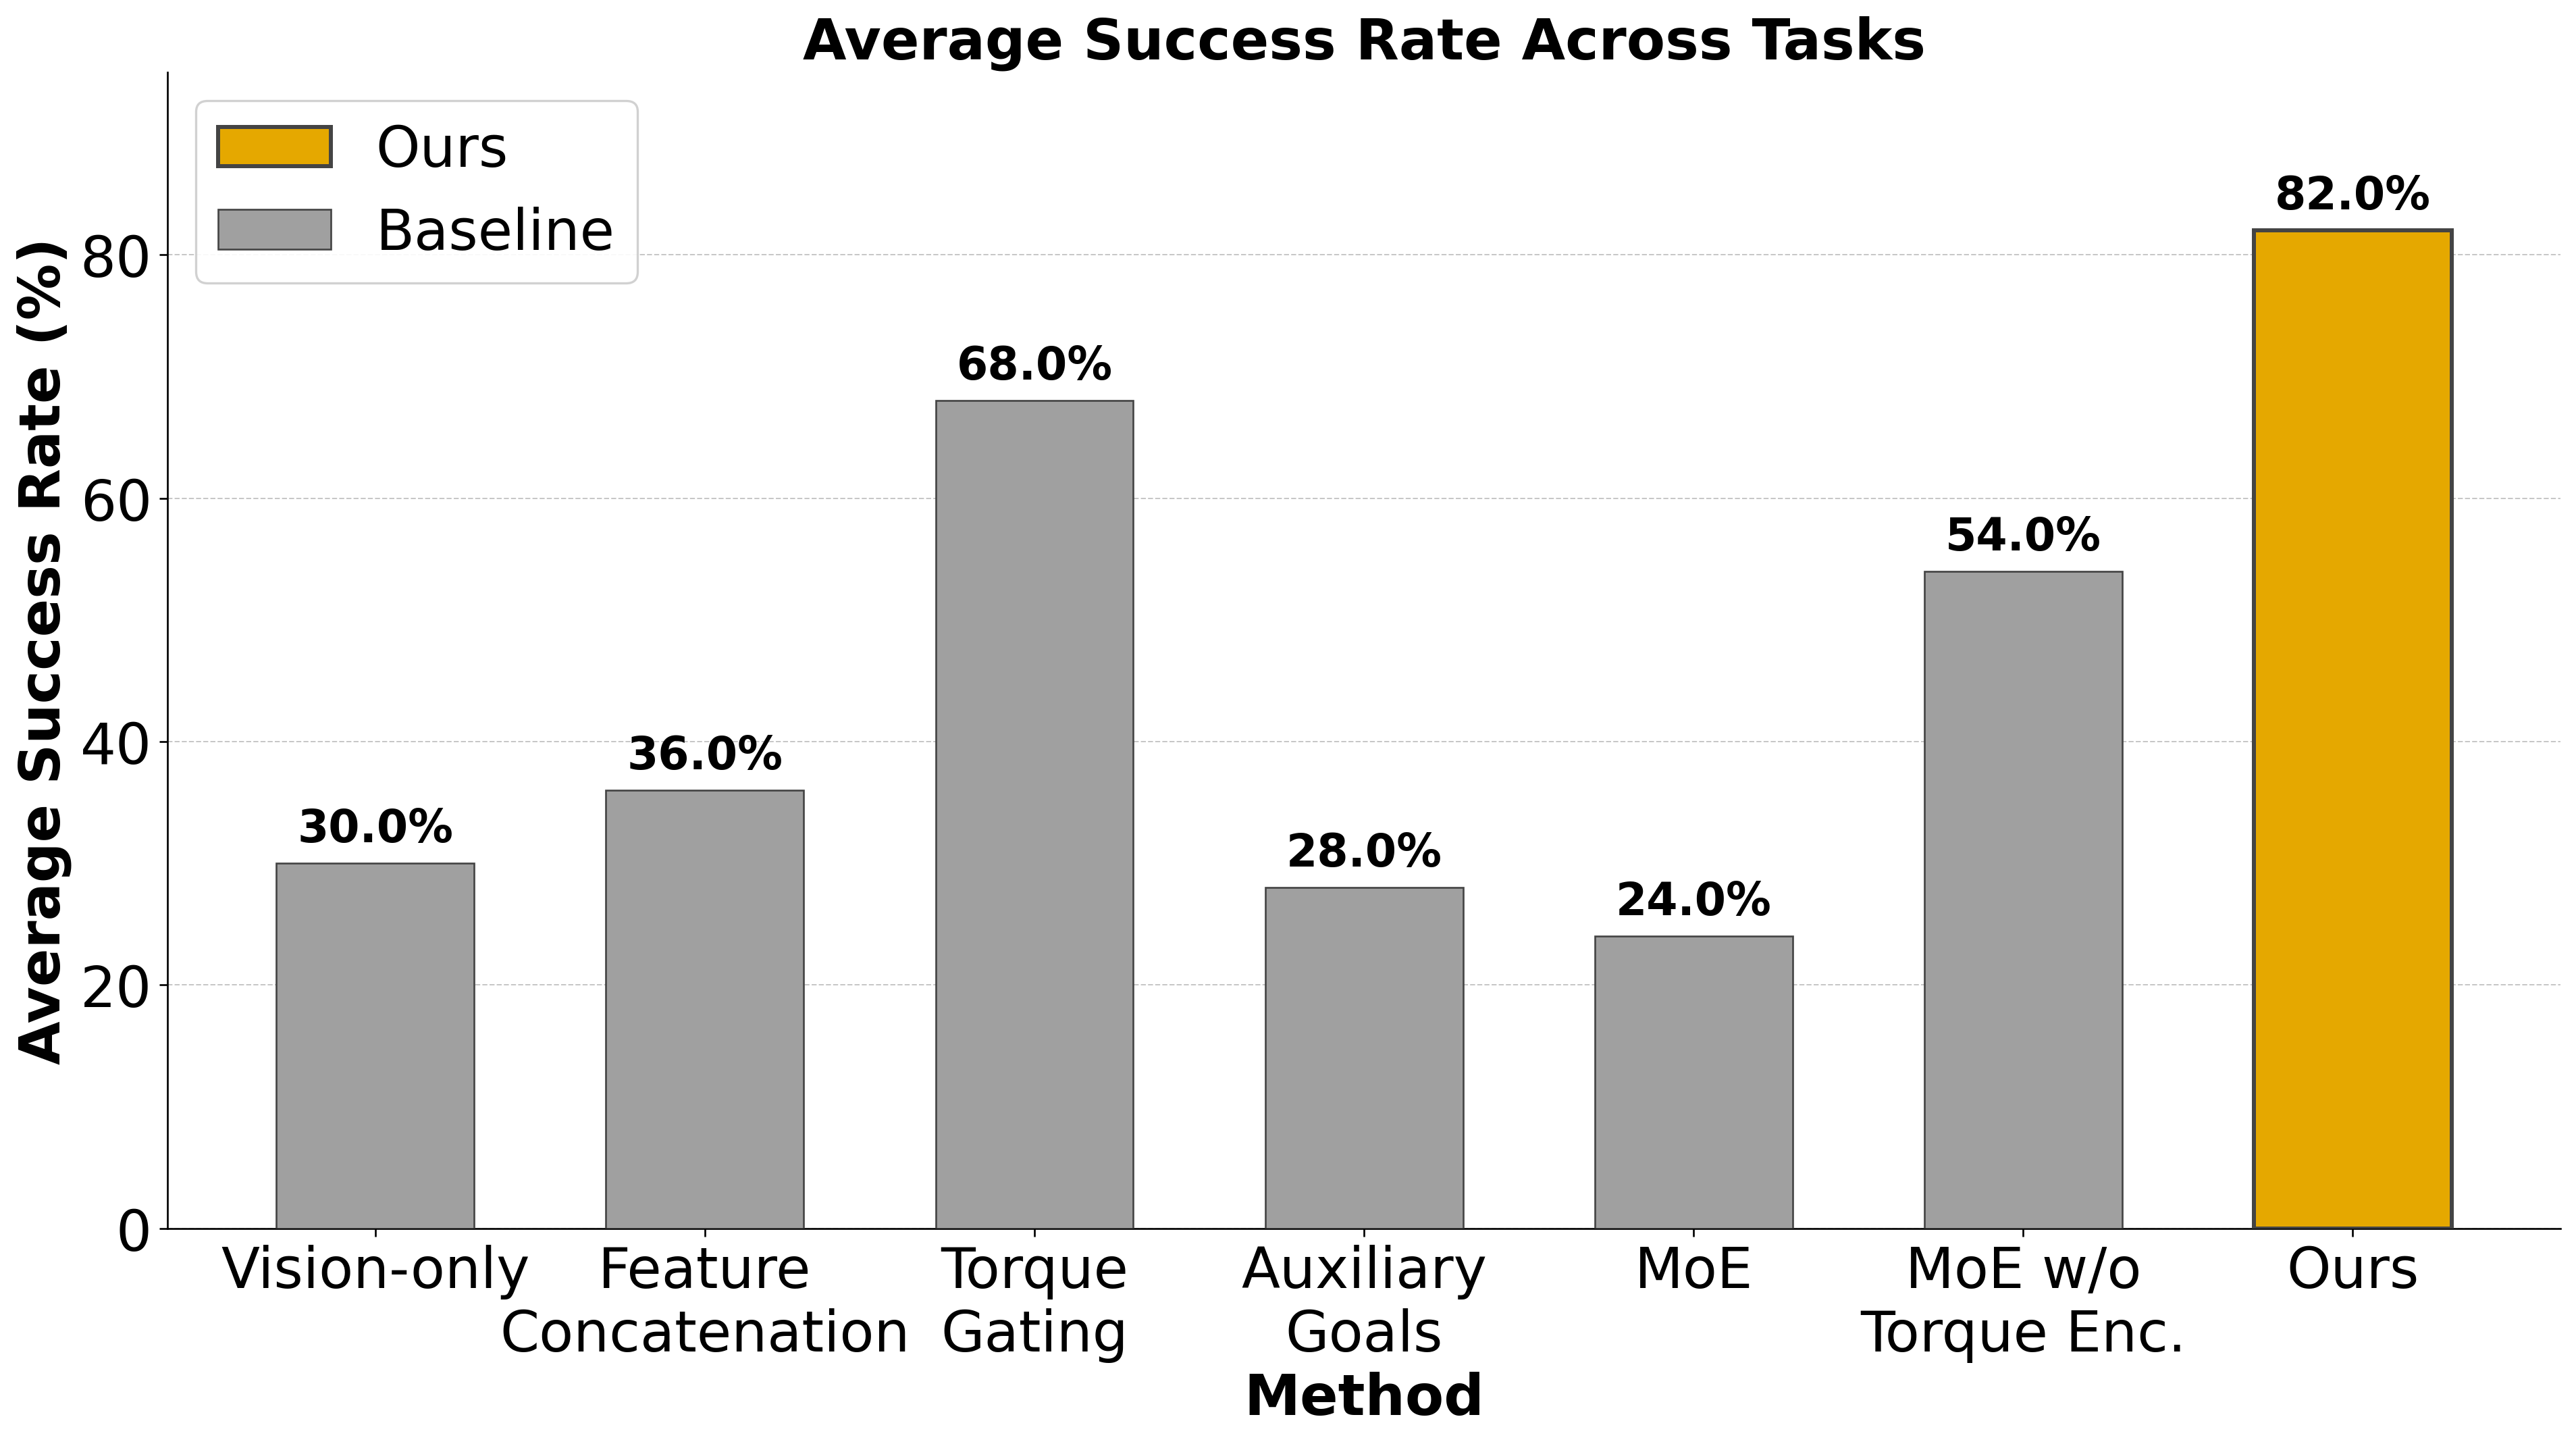

Saved at 3840x2160 px  (240 dpi)


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Parameters ──────────────────────────────────────────────
TITLE_FONTSIZE  = 25
LABEL_FONTSIZE  = 25
TICK_FONTSIZE   = 25
LEGEND_FONTSIZE = 25
BAR_VALUE_FONTSIZE = 20
FIG_WIDTH  = 16    # 16 x 240 dpi = 3840 px  (4K UHD width)
FIG_HEIGHT = 9     #  9 x 240 dpi = 2160 px  (4K UHD height)
DPI        = 240   # change to 300 for print quality at slightly above 4K
# ────────────────────────────────────────────────────────────

methods = [
    'Vision-only',
    'Feature\nConcatenation',
    'Torque\nGating',
    'Auxiliary\nGoals',
    'MoE',
    'MoE w/o\nTorque Enc.',
    'Ours',
]

avg_success = [30.0, 36.0, 68.0, 28.0, 24.0, 54.0, 82.0]

BASELINE_COLOR = '#a0a0a0'   # gray
OURS_COLOR     = '#E5A800'   # golden

colors = [BASELINE_COLOR] * len(methods)
colors[-1] = OURS_COLOR
edge_colors = ['#444444'] * len(methods)
edge_widths = [0.8] * len(methods)
edge_widths[-1] = 1.8

x = np.arange(len(methods))

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI)

bars = ax.bar(
    x, avg_success,
    color=colors,
    edgecolor=edge_colors,
    linewidth=edge_widths,
    width=0.6,
    zorder=3,
)

# Value labels on top of each bar — all bold
for bar, val in zip(bars, avg_success):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.0,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=BAR_VALUE_FONTSIZE,
        fontweight='bold',
    )

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=TICK_FONTSIZE)
ax.set_ylabel('Average Success Rate (%)', fontsize=LABEL_FONTSIZE, fontweight='bold')
ax.set_xlabel('Method', fontsize=LABEL_FONTSIZE, fontweight='bold')
ax.set_title('Average Success Rate Across Tasks', fontsize=TITLE_FONTSIZE, fontweight='bold')

ax.set_ylim(0, 95)
ax.yaxis.set_tick_params(labelsize=TICK_FONTSIZE)
ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.7, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

# Legend
ours_patch = mpatches.Patch(facecolor=OURS_COLOR,     edgecolor='#444444', linewidth=1.8, label='Ours')
base_patch = mpatches.Patch(facecolor=BASELINE_COLOR, edgecolor='#444444', linewidth=0.8, label='Baseline')
ax.legend(handles=[ours_patch, base_patch], fontsize=LEGEND_FONTSIZE, framealpha=0.9)

plt.tight_layout()
plt.savefig('avg_success_rate.png', bbox_inches='tight', dpi=DPI)
plt.show()
print(f'Saved at {int(FIG_WIDTH*DPI)}x{int(FIG_HEIGHT*DPI)} px  ({DPI} dpi)')